<a href="https://colab.research.google.com/github/peterdomjan-maker/Biomed2026/blob/main/S3_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIOMED-DATA 26 · Session 3
## Regression: predicting a number
**Predict maximum heart rate (thalach) on UCI Heart: linear regression, RMSE/MAE/R², and regularization**

> **STUDENT — fill in the blanks**
>
> Dataset: UCI Heart Disease (`ucimlrepo`, id=45). Runs in Colab: `Runtime → Run all`.
> Semmelweis University
---

In [1]:
!pip -q install ucimlrepo scikit-learn pandas matplotlib seaborn

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
from ucimlrepo import fetch_ucirepo

## 0. Load and choose the target

In [3]:
heart = fetch_ucirepo(id=45)
data = heart.data.features.copy()
# regression target: maximum heart rate achieved
y = data["thalach"]
X = data.drop(columns=["thalach"])
numeric = ["age","trestbps","chol","oldpeak"]
categorical = ["sex","cp","fbs","restecg","exang","slope","ca","thal"]
print("Target thalach — mean:", round(y.mean(),1), "range:", y.min(), "-", y.max())

Target thalach — mean: 149.6 range: 71 - 202


### Preprocessing and split

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 20% test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

pre = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical)
])

## 1. Linear regression in a pipeline
Fit a straight-line model and report the error in the target's own units (beats per minute).

In [8]:
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# Linear regression pipeline
lin = Pipeline([
    ("pre", pre),
    ("m", LinearRegression())
])

# Fit model on training data only
lin.fit(X_train, y_train)

# Predict on test data
pred = lin.predict(X_test)

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", round(rmse, 2), "| MAE:", round(mae, 2), "| R2:", round(r2, 3))

RMSE: 19.84 | MAE: 16.13 | R2: 0.334


## 2. Predicted vs actual
The first plot to draw for any regression. Points should hug the diagonal.

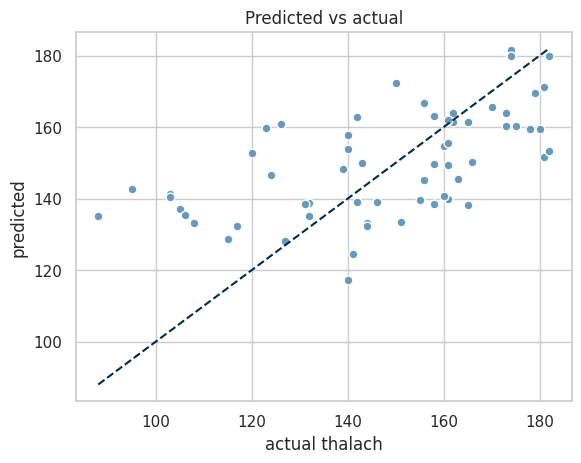

In [9]:
import matplotlib.pyplot as plt

# Scatter plot of actual vs predicted values
plt.scatter(y_test, pred, color="#6699bb", edgecolor="white", s=40)

# Diagonal reference line: perfect prediction
lim = [y_test.min(), y_test.max()]
plt.plot(lim, lim, "--", color="#002b49")

plt.xlabel("actual thalach")
plt.ylabel("predicted")
plt.title("Predicted vs actual")
plt.show()

## 3. The residual plot
Residual = actual − predicted. A shapeless band around zero is healthy; a curve means a missing pattern.

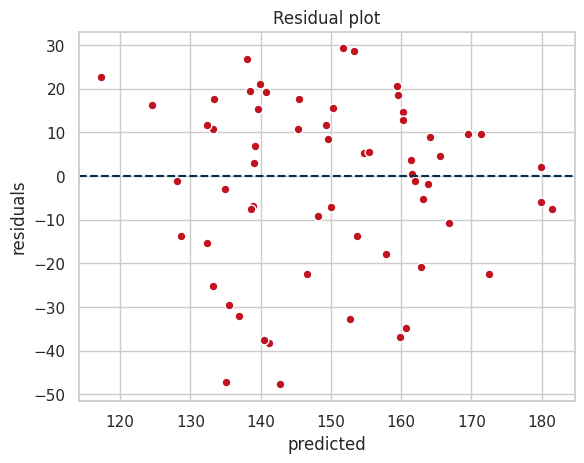

In [10]:
import matplotlib.pyplot as plt

# Residual = actual - predicted
resid = y_test - pred

# Scatter plot: residuals vs predicted values
plt.scatter(pred, resid, color="#c1121f", edgecolor="white", s=40)

# Horizontal reference line at zero
plt.axhline(0, ls="--", color="#003049")

plt.xlabel("predicted")
plt.ylabel("residuals")
plt.title("Residual plot")
plt.show()

## 4. Plain vs Ridge vs Lasso
Regularization trades a little training fit for better behaviour on new patients. Compare cross-validated RMSE.

In [11]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

for name, m in {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.5, max_iter=10000)
}.items():

    pipe = Pipeline([
        ("pre", pre),
        ("m", m)
    ])

    # 5-fold CV, scoring is negative RMSE, so we multiply by -1
    rmse = -cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    ).mean()

    print(f"{name:8s} CV RMSE = {rmse:.2f}")

Linear   CV RMSE = 18.01
Ridge    CV RMSE = 17.96
Lasso    CV RMSE = 17.80


## 5. Tuning the Ridge penalty
Too little penalty overfits; too much underfits. Find the sweet spot by cross-validation.

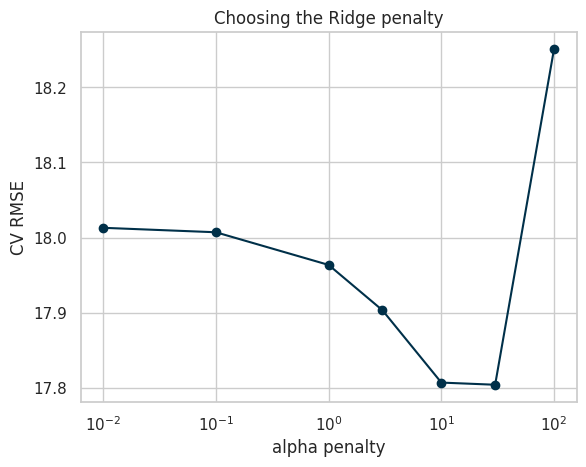

Best alpha: 30


In [12]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

alphas = [0.01, 0.1, 1, 3, 10, 30, 100]
scores = []

for a in alphas:
    pipe = Pipeline([
        ("pre", pre),
        ("m", Ridge(alpha=a))
    ])

    rmse = -cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    ).mean()

    scores.append(rmse)

plt.plot(alphas, scores, "o-", color="#003049")
plt.xscale("log")
plt.xlabel("alpha penalty")
plt.ylabel("CV RMSE")
plt.title("Choosing the Ridge penalty")
plt.show()

best_alpha = alphas[np.argmin(scores)]
print("Best alpha:", best_alpha)

## 6. A stronger regressor (peek ahead to Session 4)
A gradient-boosted tree often leads on tabular data. Compare it to the linear model.

In [14]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Stronger regression model
gb = Pipeline([
    ("pre", pre),
    ("m", HistGradientBoostingRegressor(random_state=0))
])

# Fit on training data
gb.fit(X_train, y_train)

# Predict on test data
gp = gb.predict(X_test)

# Metrics for boosted model
gb_rmse = np.sqrt(mean_squared_error(y_test, gp))
gb_mae = mean_absolute_error(y_test, gp)
gb_r2 = r2_score(y_test, gp)

print("Linear R2:", round(r2_score(y_test, pred), 3))
print("Boosted RMSE:", round(gb_rmse, 2), "| MAE:", round(gb_mae, 2), "| R2:", round(gb_r2, 3))

Linear R2: 0.334
Boosted RMSE: 19.73 | MAE: 15.41 | R2: 0.341


## Questions to think about
1. RMSE is always ≥ MAE. A large gap between them hints at what?
2. Did Ridge or Lasso beat plain linear regression here? Why might regularization help on a small dataset?


*Next session: ensembles random forests and boosting, for both classification and regression.*